# Classification d’images de fleurs avec PyTorch

Ce projet consiste à développer un modèle de Deep Learning capable de classifier différentes espèces de fleurs.
Nous utiliserons le Transfer Learning avec un modèle préentraîné afin de bénéficier des caractéristiques visuelles déjà apprises sur le dataset ImageNet.

Dans cette première partie, nous importons les bibliothèques nécessaires, définissons les chemins du projet et sélectionnons le meilleur dispositif de calcul disponible : CUDA, MPS ou CPU.

In [3]:
# Standard library
import os
import json
import time
from pathlib import Path
from collections import OrderedDict

# Numerical computing
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# PyTorch
import torch
from torch import nn, optim
from torch.utils.data import DataLoader

# Torchvision
from torchvision import datasets, transforms, models

# Image processing
from PIL import Image

## Configuration des chemins

Nous définissons les chemins vers les dossiers d’entraînement, de validation et de test.


In [7]:
# Déterminer automatiquement le dossier principal du projet
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_dir = current_directory.parent
else:
    project_dir = current_directory

# Chemins principaux
data_dir = project_dir / "flowers"
train_dir = data_dir / "train"
valid_dir = data_dir / "valid"
test_dir = data_dir / "test"

category_names_path = project_dir / "cat_to_name.json"

print(f"Dossier du projet : {project_dir}")
print(f"Dossier des données : {data_dir}")
print(f"Train existe : {train_dir.exists()}")
print(f"Validation existe : {valid_dir.exists()}")
print(f"Test existe : {test_dir.exists()}")

Dossier du projet : /Users/donbosenga/Desktop/Bosenga_Don_master1_ia_oct2025_1
Dossier des données : /Users/donbosenga/Desktop/Bosenga_Don_master1_ia_oct2025_1/flowers
Train existe : True
Validation existe : True
Test existe : True


## Sélection du dispositif de calcul

PyTorch peut exécuter les calculs sur différents dispositifs :
- CUDA pour les cartes graphiques NVIDIA ;
- MPS pour les Mac équipés d’une puce Apple Silicon ;
- CPU lorsqu’aucun accélérateur graphique n’est disponible.

Le programme sélectionne automatiquement le meilleur dispositif disponible.

In [8]:
# Sélectionner automatiquement le meilleur dispositif disponible
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Dispositif utilisé : {device}")

Dispositif utilisé : mps


## Chargement des noms des catégories

Dans le dataset, les classes sont représentées par des identifiants numériques.

Le fichier `cat_to_name.json` permet de convertir ces identifiants en noms réels de fleurs afin de rendre les prédictions plus compréhensibles.

In [10]:
# Charger la correspondance entre les numéros de classes et les noms de fleurs
with open(category_names_path, "r", encoding="utf-8") as file:
    cat_to_name = json.load(file)

print(f"Nombre de catégories : {len(cat_to_name)}")

# Afficher quelques exemples
for class_id, flower_name in list(cat_to_name.items())[:3]:
    print(f"Classe {class_id} : {flower_name}")

Nombre de catégories : 102
Classe 21 : fire lily
Classe 3 : canterbury bells
Classe 45 : bolero deep blue


## Prétraitement et augmentation des images



In [11]:
# Valeurs de normalisation utilisées par les modèles préentraînés sur ImageNet
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Transformations pour le jeu d'entraînement
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Transformations pour la validation et le test
evaluation_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

## Chargement des datasets avec ImageFolder

Le dataset est organisé en sous-dossiers, chaque sous-dossier représentant une classe de fleurs.

`ImageFolder` attribue automatiquement un identifiant numérique à chaque classe et applique les transformations définies précédemment.

In [12]:
# Charger les jeux de données depuis leurs dossiers respectifs
image_datasets = {
    "train": datasets.ImageFolder(train_dir, transform=train_transforms),
    "valid": datasets.ImageFolder(valid_dir, transform=evaluation_transforms),
    "test": datasets.ImageFolder(test_dir, transform=evaluation_transforms)
}

# Afficher quelques informations utiles
print(f"Nombre d'images d'entraînement : {len(image_datasets['train'])}")
print(f"Nombre d'images de validation : {len(image_datasets['valid'])}")
print(f"Nombre d'images de test : {len(image_datasets['test'])}")
print(f"Nombre de classes : {len(image_datasets['train'].classes)}")

Nombre d'images d'entraînement : 6552
Nombre d'images de validation : 818
Nombre d'images de test : 819
Nombre de classes : 102


## Création des DataLoaders
Les DataLoaders permettent de charger les images par petits groupes appelés batches.

In [13]:
batch_size = 32

dataloaders = {
    "train": DataLoader(
        image_datasets["train"],
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    ),
    "valid": DataLoader(
        image_datasets["valid"],
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    ),
    "test": DataLoader(
        image_datasets["test"],
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )
}

print("DataLoaders créés avec succès.")

DataLoaders créés avec succès.


## Visualisation des images d'entraînement

Les images ont été normalisées pour correspondre aux données utilisées lors de l'entraînement du modèle sur ImageNet.
Avant de les afficher, nous devons donc annuler cette normalisation afin de retrouver des couleurs naturelles.

In [15]:
def imshow(image, axis=None, title=None):
    """Affiche une image PyTorch après annulation de la normalisation."""
    
    if axis is None:
        _, axis = plt.subplots()

    # Convertir le tenseur PyTorch en tableau NumPy
    image = image.numpy().transpose((1, 2, 0))

    # Annuler la normalisation ImageNet
    mean_array = np.array([0.485, 0.456, 0.406])
    std_array = np.array([0.229, 0.224, 0.225])
    image = std_array * image + mean_array

    # Limiter les valeurs entre 0 et 1
    image = np.clip(image, 0, 1)

    axis.imshow(image)
    axis.axis("off")

    if title is not None:
        axis.set_title(title)

    return axis

## Affichage d'un échantillon du dataset

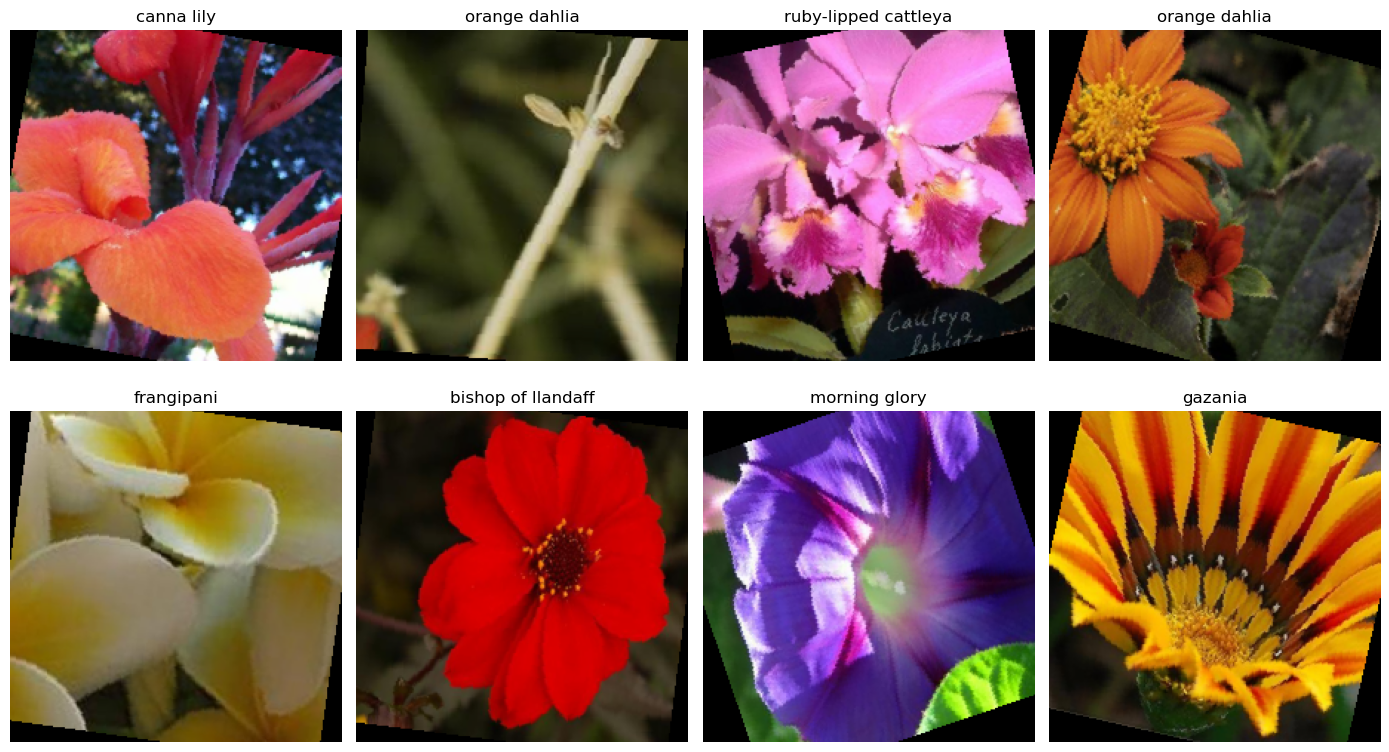

In [16]:
images, labels = next(iter(dataloaders["train"]))

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

for axis, image, label in zip(axes.ravel(), images[:8], labels[:8]):
    class_id = image_datasets["train"].classes[label.item()]
    flower_name = cat_to_name.get(class_id, class_id)

    imshow(
        image,
        axis=axis,
        title=flower_name
    )

plt.tight_layout()
plt.show()

## Création du modèle avec Transfer Learning

Nous utilisons ResNet18, un réseau de neurones convolutif préentraîné sur ImageNet.

In [17]:
# Charger les poids préentraînés sur ImageNet
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Geler les paramètres du réseau convolutif
for parameter in model.parameters():
    parameter.requires_grad = False

print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


## Remplacement de la couche de classification

La couche finale originale de ResNet18 contient 1 000 sorties correspondant aux catégories ImageNet.

Nous la remplaçons par un classifieur adapté à notre problème comportant 102 classes.

In [18]:
number_of_classes = len(image_datasets["train"].classes)
print(f"Nombre de classes : {number_of_classes}")
number_of_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(number_of_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, number_of_classes)
)

model = model.to(device)

print(model.fc)

Nombre de classes : 102
Sequential(
  (0): Linear(in_features=512, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=102, bias=True)
)


## Fonction de perte et optimiseur

In [19]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print(f"Modèle placé sur : {device}")
print(f"Nombre de classes : {number_of_classes}")

Modèle placé sur : mps
Nombre de classes : 102
